# Human Activity Recognition from Health Sensor Data

Objective: classify 10 activities using health sensor features and compare multiple models.

This notebook covers EDA, preprocessing, model training, evaluation, and figure export for the report.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
 )
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style="whitegrid")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

I0000 00:00:1777731291.950967    4258 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777731291.958942    4258 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777731292.685994    4258 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777731302.181448    4258 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [57]:
df = pd.read_csv("../data/health_fitness_dataset.csv")
df.head()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


In [58]:
df.shape

(687701, 22)

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   participant_id            687701 non-null  int64  
 1   date                      687701 non-null  str    
 2   age                       687701 non-null  int64  
 3   gender                    687701 non-null  str    
 4   height_cm                 687701 non-null  float64
 5   weight_kg                 687701 non-null  float64
 6   activity_type             687701 non-null  str    
 7   duration_minutes          687701 non-null  int64  
 8   intensity                 687701 non-null  str    
 9   calories_burned           687701 non-null  float64
 10  avg_heart_rate            687701 non-null  int64  
 11  hours_sleep               687701 non-null  float64
 12  stress_level              687701 non-null  int64  
 13  daily_steps               687701 non-null  int64  
 14 

In [60]:
missing = df.isna().sum().to_frame("missing")
missing["missing_pct"] = (missing["missing"] / len(df)) * 100
missing.sort_values("missing", ascending=False)

,missing,missing_pct
health_condition,490275,71.291884
participant_id,0,0.000000
age,0,0.000000
gender,0,0.000000
height_cm,0,0.000000
date,0,0.000000
weight_kg,0,0.000000
activity_type,0,0.000000
intensity,0,0.000000
duration_minutes,0,0.000000


In [61]:
drop_cols = [c for c in ["participant_id", "date"] if c in df.columns]
df = df.drop(columns=drop_cols)
df.shape

(687701, 20)

In [62]:
target_col = "activity_type"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found. Available: {list(df.columns)}")
print("Data points:", len(df))
print("Features:", df.shape[1] - 1)
df[target_col].value_counts()

Data points: 687701
Features: 19


activity_type
Yoga               69961
Weight Training    69661
HIIT               69376
Dancing            69193
Cycling            69187
Basketball         68536
Tennis             68533
Walking            68077
Swimming           68032
Running            67145
Name: count, dtype: int64

In [64]:
numerical_data = df.select_dtypes(include=["float64", "int64"])
categorical_data = df.select_dtypes(include=["str"])
numerical_data.head()

,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
0,56,165.3,53.7,41,3.3,103,6.6,3,7128,1.5,19.6,69.5,110.7,72.9,0.04
1,56,165.3,53.9,28,2.9,102,8.1,7,7925,1.8,19.6,69.5,110.7,72.9,0.07
2,56,165.3,54.2,21,2.6,126,6.2,7,7557,2.7,19.6,69.5,110.7,72.9,0.09
3,56,165.3,54.4,99,10.7,141,7.2,8,11120,2.6,19.6,69.5,110.7,72.9,0.21
4,56,165.3,54.7,100,12.7,112,7.1,1,5406,1.5,19.6,69.5,110.7,72.9,0.33


EDA - Numerical Features

In [65]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50
weight_kg,687701.0,94.921981,22.461801,45.30,78.20,94.60,110.50,188.40
duration_minutes,687701.0,70.011671,29.147251,20.00,45.00,70.00,95.00,120.00
calories_burned,687701.0,15.381302,9.985552,0.80,7.80,13.00,20.70,92.00
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00
hours_sleep,687701.0,7.048799,0.972068,4.00,6.40,7.00,7.70,10.00
stress_level,687701.0,5.252389,2.770029,1.00,3.00,5.00,8.00,10.00
daily_steps,687701.0,8628.370918,2054.756608,-419.00,7203.00,8607.00,10027.00,17241.00
hydration_level,687701.0,2.499427,0.579050,1.50,2.00,2.50,3.00,3.50


In [66]:
numerical_data.skew().sort_values(ascending=False)

calories_burned             1.235929
bmi                         0.467859
avg_heart_rate              0.360952
weight_kg                   0.191474
height_cm                   0.179715
blood_pressure_diastolic    0.132936
stress_level                0.073721
daily_steps                 0.062185
fitness_level               0.023257
resting_heart_rate          0.008333
hours_sleep                 0.007850
hydration_level             0.001448
duration_minutes           -0.001944
age                        -0.063646
blood_pressure_systolic    -0.072306
dtype: float64

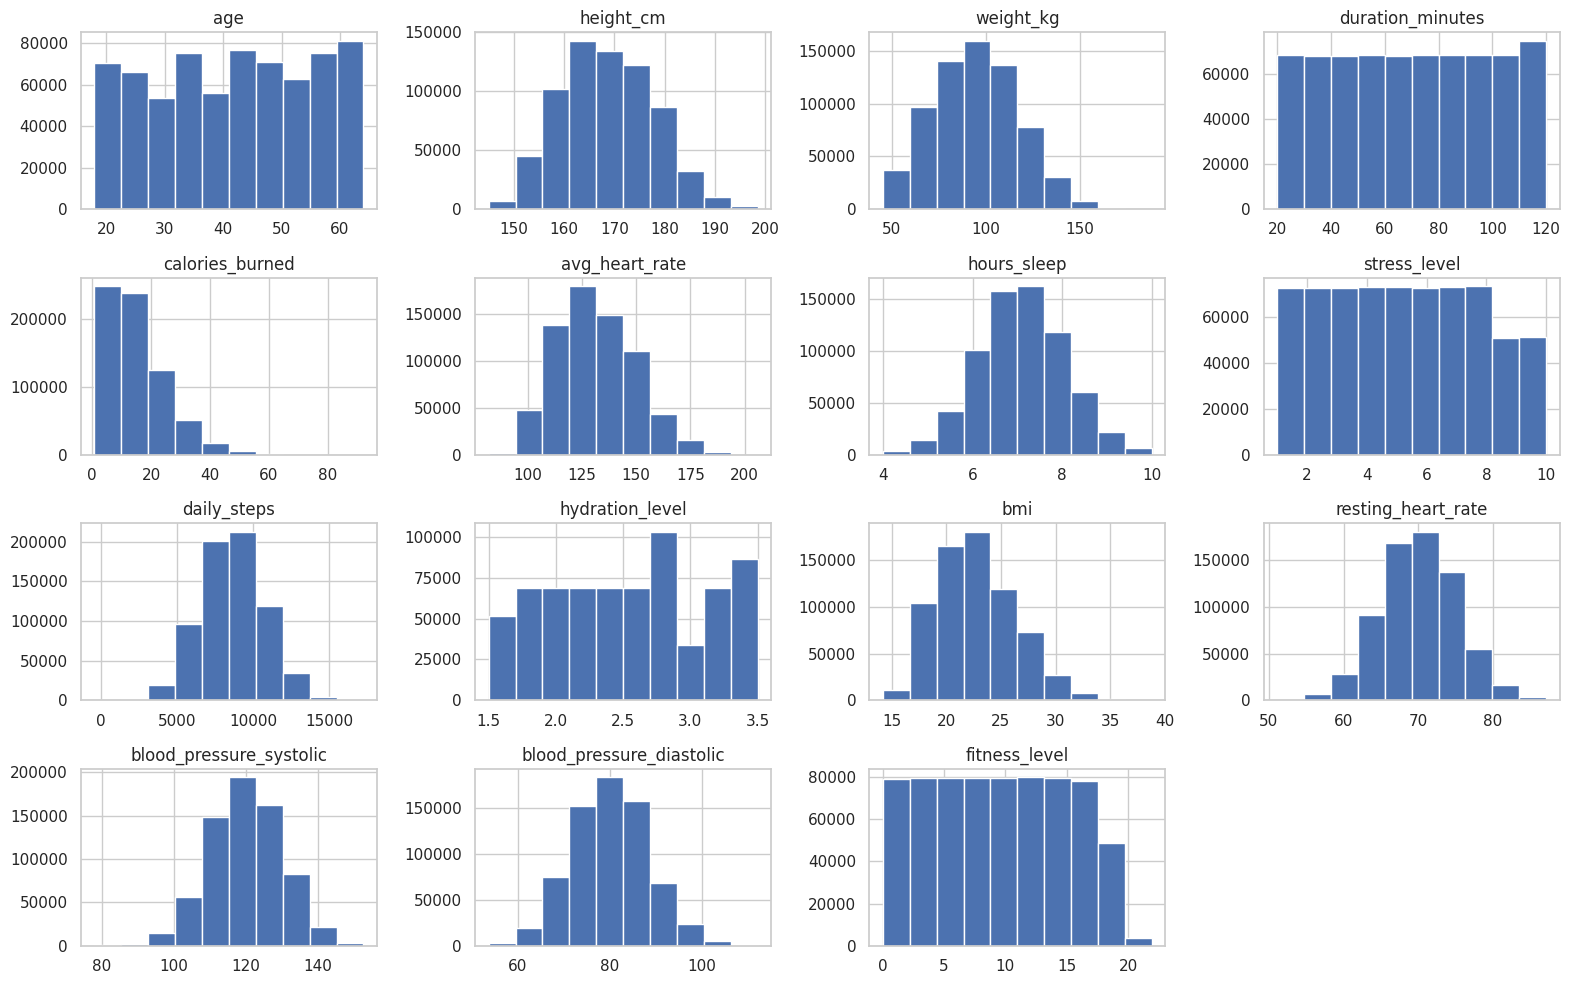

In [67]:
numerical_data.hist(figsize=(16, 10))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_hist.png", dpi=300)
plt.show()

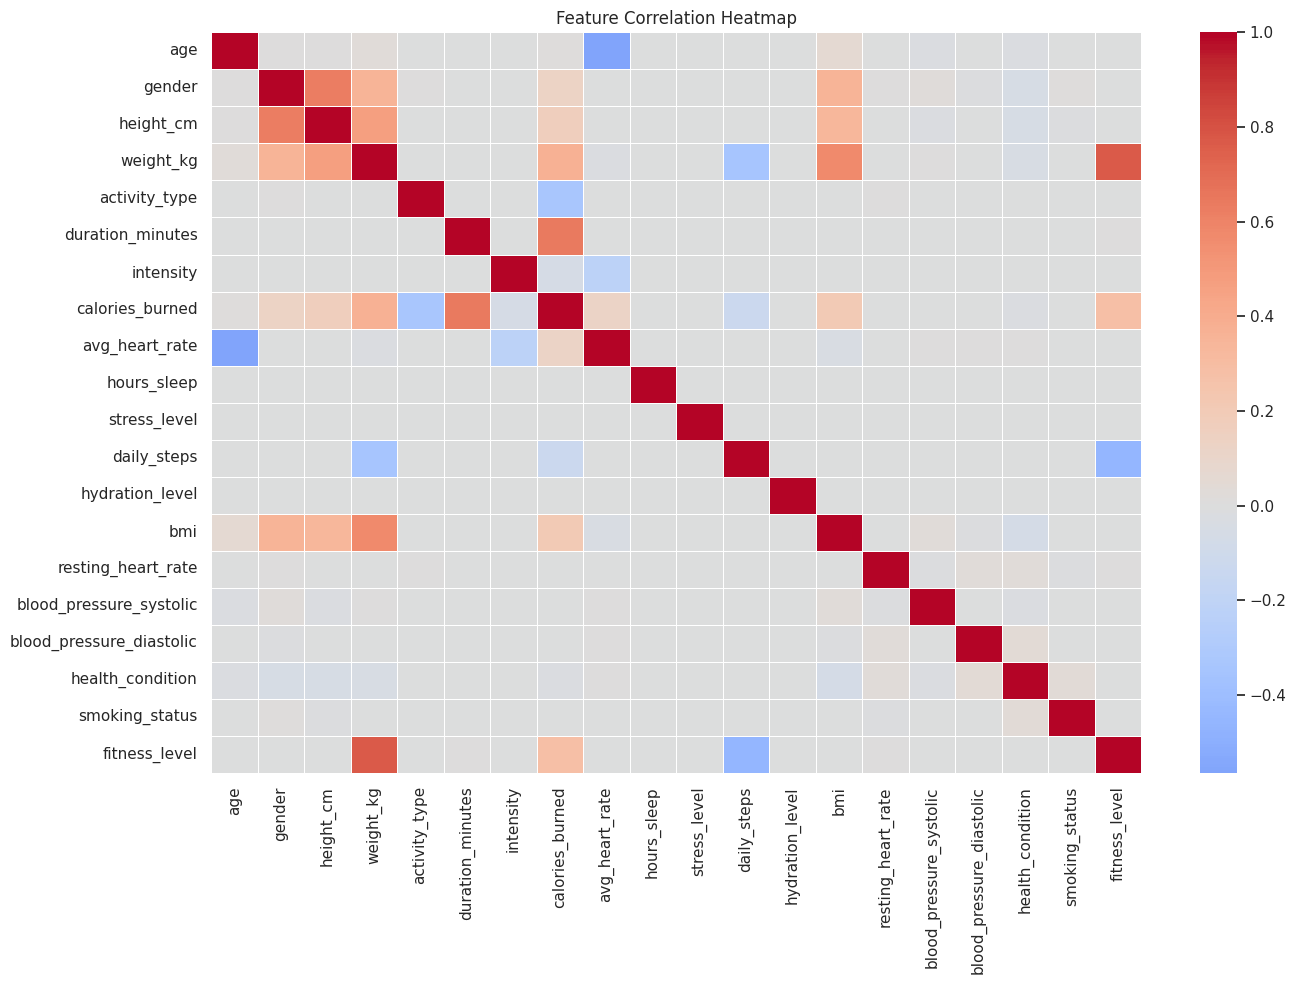

In [68]:
df_corr = df.copy()
cat_cols = df_corr.select_dtypes(include=["str"]).columns
if len(cat_cols) > 0:
    oe = OrdinalEncoder()
    df_corr[cat_cols] = oe.fit_transform(df_corr[cat_cols])

corr = df_corr.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

EDA - Categorical Features

In [69]:
categorical_data.describe().T

,count,unique,top,freq
gender,687701,3,F,338856
activity_type,687701,10,Yoga,69961
intensity,687701,3,Medium,343433
health_condition,197426,3,Hypertension,99437
smoking_status,687701,3,Never,416800


In [70]:
categorical_data.nunique().sort_values(ascending=False)

activity_type       10
gender               3
intensity            3
health_condition     3
smoking_status       3
dtype: int64

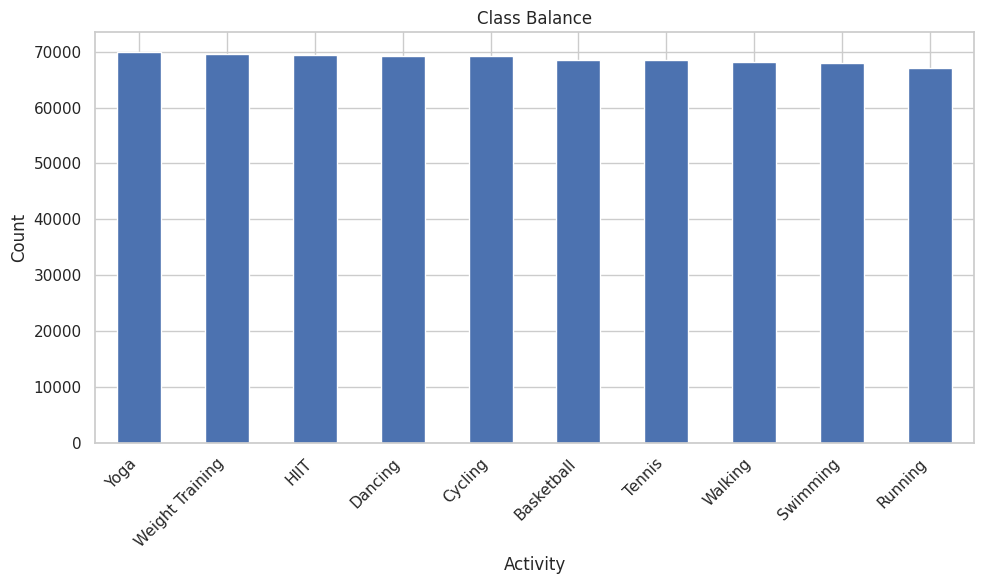

In [71]:
plt.figure(figsize=(10, 6))
df[target_col].value_counts().plot(kind="bar")
plt.title("Class Balance")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance.png", dpi=300)
plt.show()

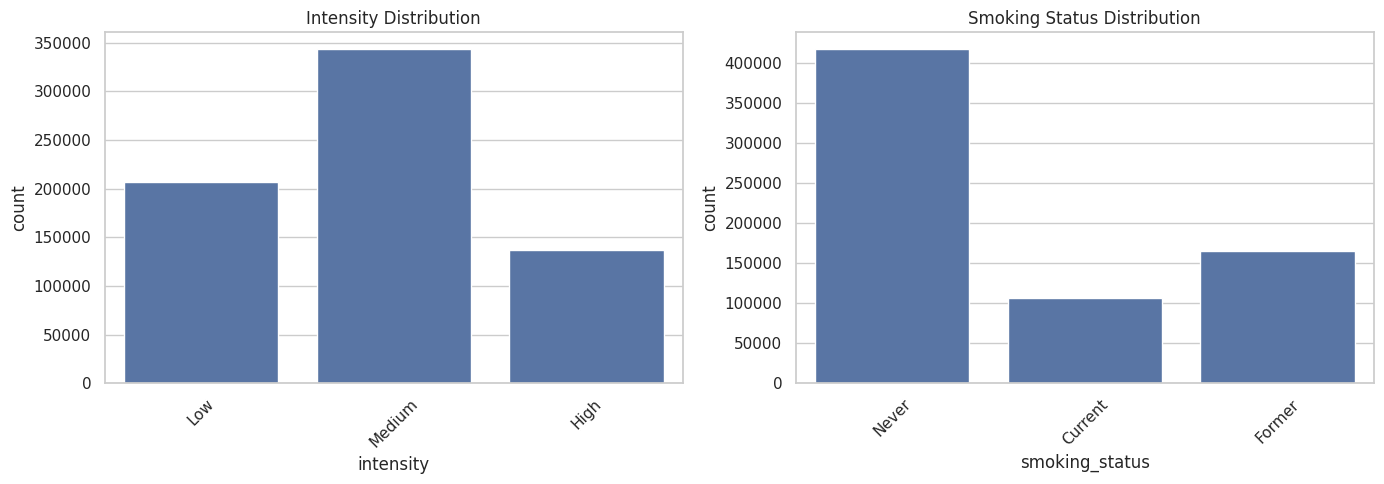

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if "intensity" in df.columns:
    sns.countplot(data=df, x="intensity", ax=axes[0])
    axes[0].set_title("Intensity Distribution")
    axes[0].tick_params(axis="x", rotation=45)
if "smoking_status" in df.columns:
    sns.countplot(data=df, x="smoking_status", ax=axes[1])
    axes[1].set_title("Smoking Status Distribution")
    axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_distributions.png", dpi=300)
plt.show()

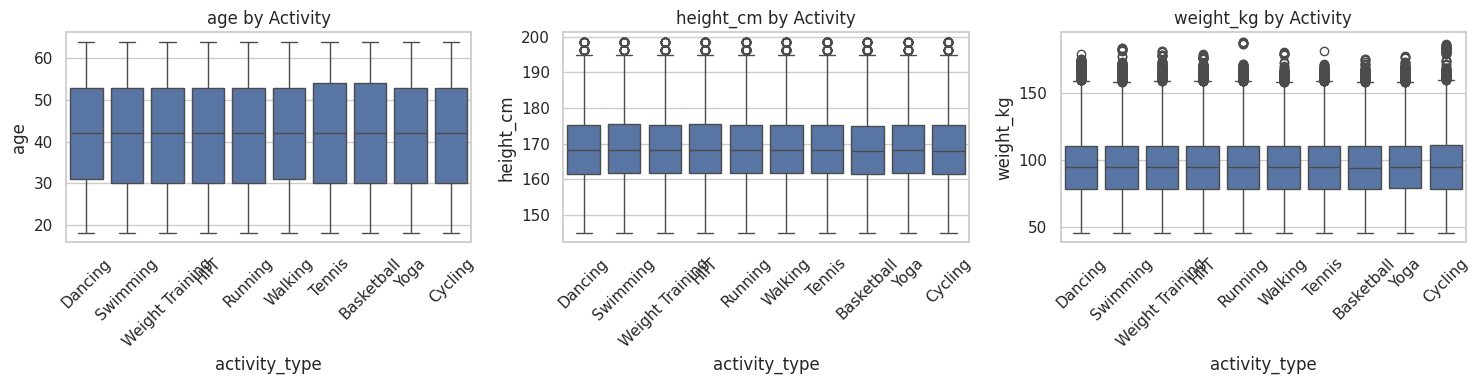

In [73]:
box_cols = numerical_data.columns[:3]
fig, axes = plt.subplots(1, len(box_cols), figsize=(5 * len(box_cols), 4))
if len(box_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} by Activity")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_boxplots_by_activity.png", dpi=300)
plt.show()

In [75]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

Preprocessing

In [77]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["str"]).columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

class_names = label_encoder.classes_
X_train_prep.shape, X_val_prep.shape, X_test_prep.shape

((481390, 27), (103155, 27), (103156, 27))

Model Training and Evaluation Helpers

In [78]:
results = {}
predictions = {}
probabilities = {}

def evaluate_and_store(name, y_true, y_pred, y_proba=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }
    predictions[name] = y_pred
    if y_proba is not None:
        probabilities[name] = y_proba
    print(f"{name} accuracy: {accuracy:.4f}")

KNN

In [81]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_prep, y_train)
knn_pred = knn.predict(X_test_prep)
knn_proba = knn.predict_proba(X_test_prep)
evaluate_and_store("KNN", y_test, knn_pred, knn_proba)

KNN accuracy: 0.2220


Decision Tree

In [82]:
dt = DecisionTreeClassifier()
dt.fit(X_train_prep, y_train)
dt_pred = dt.predict(X_test_prep)
dt_proba = dt.predict_proba(X_test_prep)
evaluate_and_store("Decision Tree", y_test, dt_pred, dt_proba)

Decision Tree accuracy: 0.8933


Naive Bayes

In [83]:
nb = GaussianNB()
nb.fit(X_train_prep, y_train)
nb_pred = nb.predict(X_test_prep)
nb_proba = nb.predict_proba(X_test_prep)
evaluate_and_store("Naive Bayes", y_test, nb_pred, nb_proba)

Naive Bayes accuracy: 0.1967


Neural Network (Softmax)

In [86]:
num_classes = len(class_names)
nn_model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(X_train_prep.shape[1],)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ]
)

nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
]

history = nn_model.fit(
    X_train_prep,
    y_train_enc,
    validation_data=(X_val_prep, y_val_enc),
    epochs=50,
    batch_size=32,
    verbose=0,
    callbacks=callbacks,
)

nn_proba = nn_model.predict(X_test_prep, verbose=0)
nn_pred_enc = np.argmax(nn_proba, axis=1)
nn_pred = label_encoder.inverse_transform(nn_pred_enc)
evaluate_and_store("Neural Net", y_test, nn_pred, nn_proba)

plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Neural Net Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nn_training_loss.png", dpi=300)
plt.show()

E0000 00:00:1777732565.481231    4258 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777732565.482121   14830 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777732565.509026    4258 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


KeyboardInterrupt: 

KMeans (Unsupervised Clustering)

In [ ]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init="auto")
kmeans_labels = kmeans.fit_predict(X_train_prep)

sil_score = silhouette_score(X_train_prep, kmeans_labels)
ari = adjusted_rand_score(y_train, kmeans_labels)
nmi = normalized_mutual_info_score(y_train, kmeans_labels)

print(f"Silhouette: {sil_score:.4f}, ARI: {ari:.4f}, NMI: {nmi:.4f}")

cluster_vs_label = pd.crosstab(y_train, kmeans_labels, normalize="index")
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_vs_label, cmap="Blues")
plt.title("KMeans Clusters vs True Labels (Train)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_clusters_heatmap.png", dpi=300)
plt.show()

Model Comparison

In [ ]:
results_df = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
results_df

ax = results_df[["accuracy", "precision", "recall"]].plot(kind="bar", figsize=(8, 5))
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison.png", dpi=300)
plt.show()

In [ ]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{name} Confusion Matrix")
    plt.tight_layout()
    filename = name.lower().replace(" ", "_")
    plt.savefig(FIGURES_DIR / f"confusion_matrix_{filename}.png", dpi=300)
    plt.show()

In [ ]:
y_test_bin = label_binarize(y_test, classes=class_names)
plt.figure(figsize=(7, 6))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("Micro-Average ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_micro_average.png", dpi=300)
plt.show()